In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Colab Notebooks/APRENDIZAJE2"

In [ ]:
#INSTALAR LIBRERIAS NECESARIAS
!pip install lightgbm
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.6 MB/s eta 0:00:00


In [ ]:
#IMPORTAR LIBRERIAS
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import numpy as np
from datetime import datetime
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input, BatchNormalization, ReLU, Add, Dropout
from prophet import Prophet
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from tensorflow.keras.layers import LSTM
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler

#CARGAR LOS DATOS
energy = pd.read_csv(f"{base_path}/energy_train.csv")

/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
#VISUALIZAR DATOS
energy.head()

,Datetime,Energy
0,2002-12-31 01:00:00,5077.0
1,2002-12-31 02:00:00,4939.0
2,2002-12-31 03:00:00,4885.0
3,2002-12-31 04:00:00,4857.0
4,2002-12-31 05:00:00,4930.0


In [ ]:
# Asegurar que la columna 'Datetime' esté en formato datetime
energy['Datetime'] = pd.to_datetime(energy['Datetime'])

# Configurar 'Datetime' como índice del DataFrame
energy.set_index('Datetime', inplace=True)
energy = energy.sort_index()

#comprobar nulos y duplicados
print(energy.index.duplicated().sum())
print(energy['Energy'].isnull().sum())
print(energy[energy['Energy'].isnull()])

# Mostrar los resultados donde la condición es verdadera
print(len(energy))
energy.head()

2
0
Empty DataFrame
Columns: [Energy]
Index: []
124870


,Energy
Datetime,
2002-04-01 01:00:00,4374.0
2002-04-01 02:00:00,4306.0
2002-04-01 03:00:00,4322.0
2002-04-01 04:00:00,4359.0
2002-04-01 05:00:00,4436.0


In [ ]:
#ELIMINAR DUPLICADOS
duplicados_filas = energy[energy.index.duplicated()]
print(f"Filas con índice duplicado:\n{duplicados_filas}")

Filas con índice duplicado:
                     Energy
Datetime                   
2014-11-02 02:00:00  4613.0
2015-11-01 02:00:00  3832.0


In [ ]:
#VERIFICAR LA ELIMINACION
energy = energy.loc[~energy.index.duplicated(keep='first')]
print(energy.index.duplicated().sum())
print(len(energy))

0
124868


In [ ]:
#BUSQUEDA DE FECHAS FALTANTES, CREANDO UN INDICE NUEVO
full_index = pd.date_range(start=energy.index.min(), end=energy.index.max(), freq='h')

# Comparar el índice actual con el índice completo
missing_intervals = full_index.difference(energy.index)
energy = energy.reindex(energy.index.union(missing_intervals))

# Ordenar el DataFrame por el índice
energy = energy.sort_index()

# Interpolar los valores faltantes solo en la columna 'Energy'
energy['Energy'] = energy['Energy'].interpolate(method='linear')

# Verificar los resultados
print(energy.loc[missing_intervals])  # Mostrar los valores añadidos

# Mostrar los intervalos faltantes
print(f"Cantidad de intervalos faltantes: {len(missing_intervals)}")

print(len(energy))

                     Energy
2002-04-07 03:00:00  4864.5
2002-10-27 02:00:00  4159.0
2003-04-06 03:00:00  4370.5
2003-10-26 02:00:00  4174.0
2004-04-04 03:00:00  4707.5
2004-10-31 02:00:00  4161.0
2005-04-03 03:00:00  5017.5
2005-10-30 02:00:00  4790.0
2006-04-02 03:00:00  3762.5
2006-10-29 02:00:00  4499.5
2007-03-11 03:00:00  4438.0
2007-11-04 02:00:00  4245.5
2008-03-09 03:00:00  5648.0
2008-11-02 02:00:00  3837.5
2009-03-08 03:00:00  3562.0
2009-11-01 02:00:00  3812.5
2010-03-14 03:00:00  4210.5
2010-11-07 02:00:00  4645.5
2010-12-10 00:00:00  6626.0
2011-03-13 03:00:00  4247.0
2011-11-06 02:00:00  4613.5
2012-03-11 03:00:00  4845.5
2012-11-04 02:00:00  4429.0
2013-03-10 03:00:00  6001.5
2013-11-03 02:00:00  4023.5
2014-03-09 03:00:00  4826.0
2015-03-08 03:00:00  5388.5
2016-03-13 03:00:00  3845.0
Cantidad de intervalos faltantes: 28
124896


In [ ]:
#VOLVER A PONER NOMBRE AL INDICE
energy.index.name = 'Datetime'

print(energy.head())

                     Energy
Datetime                   
2002-04-01 01:00:00  4374.0
2002-04-01 02:00:00  4306.0
2002-04-01 03:00:00  4322.0
2002-04-01 04:00:00  4359.0
2002-04-01 05:00:00  4436.0


In [ ]:
# validador de estacionalidad ADF
adfuller(energy)

(-20.356899047142935,
 0.0,
 72,
 124823,
 {'1%': -3.430402389659626,
  '5%': -2.861563155459512,
  '10%': -2.566782324831993},
 1453220.642960102)

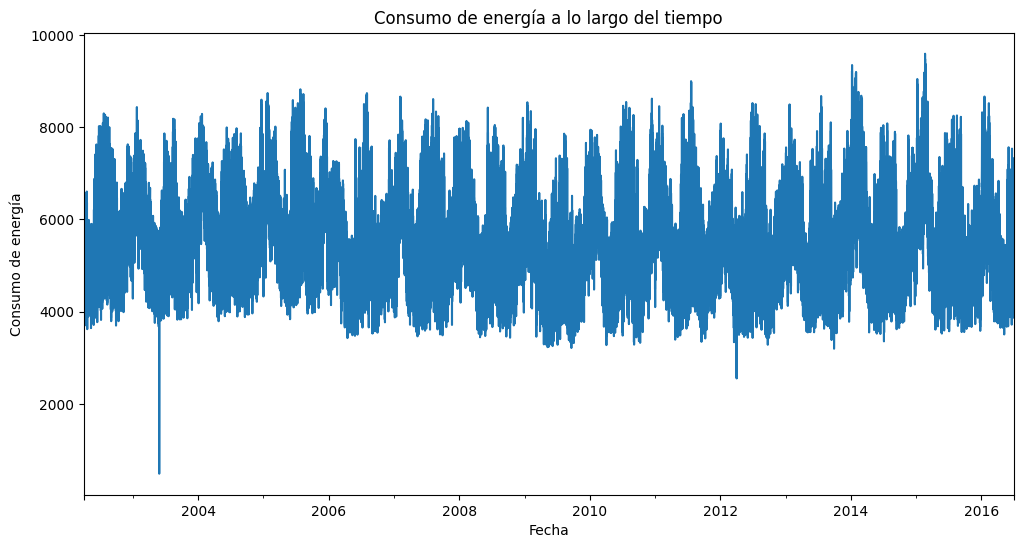

In [ ]:
#VISUALIZAR LA GRAFICA TEMPORAL
energy['Energy'].plot(figsize=(12, 6))
plt.title('Consumo de energía a lo largo del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Consumo de energía')
plt.show()

# Modelo con Analisis avanzado.

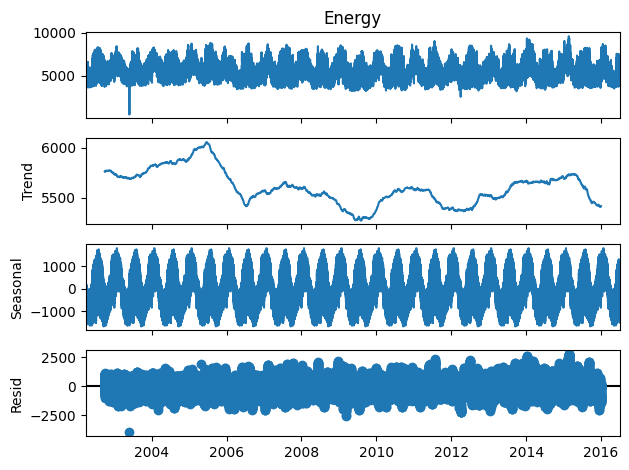

In [ ]:
# Descomposición aditiva
result = seasonal_decompose(energy['Energy'], model='additive', period=8760)
result.plot()
plt.show()

In [ ]:
#DIVIDIR EL CONJUNTO POR FECHAS
energy = energy.sort_index()
energy.head()
train = energy['2002-04-01 01:00:00':'2015-04-01 00:00:00']
test = energy['2015-04-01 01:00:00':]

train = train.asfreq('h')
test = test.asfreq('h')

print(test.tail())
print(f"Tamaño de entrenamiento: {len(train)}")
print(f"Tamaño de prueba: {len(test)}")
print(train.index.freq)

                     Energy
Datetime                   
2016-06-29 20:00:00  5828.0
2016-06-29 21:00:00  5659.0
2016-06-29 22:00:00  5606.0
2016-06-29 23:00:00  5187.0
2016-06-30 00:00:00  4653.0
Tamaño de entrenamiento: 113952
Tamaño de prueba: 10944
<Hour>


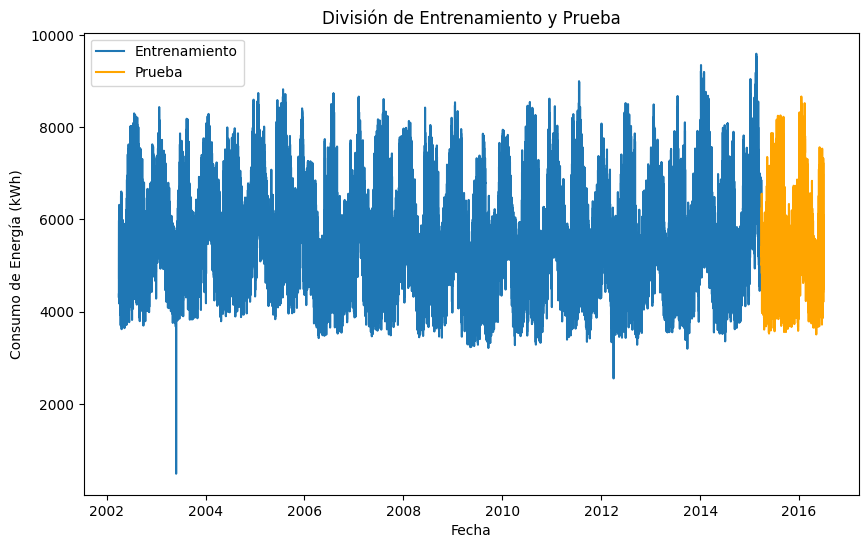

In [ ]:
#GRAFICAR LA DIVISION
plt.figure(figsize=(10, 6))
plt.plot(train, label='Entrenamiento')
plt.plot(test, label='Prueba', color='orange')
plt.title('División de Entrenamiento y Prueba')
plt.xlabel('Fecha')
plt.ylabel('Consumo de Energía (kWh)')
plt.legend()
plt.show()

# Modelo Red neuronal

Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3561/3561 ━━━━━━━━━━━━━━━━━━━━ 95s 26ms/step - loss: 31933472.0000
Epoch 2/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 140s 25ms/step - loss: 29960712.0000
Epoch 3/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 144s 26ms/step - loss: 28017990.0000
Epoch 4/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 142s 26ms/step - loss: 26138586.0000
Epoch 5/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 91s 26ms/step - loss: 24379330.0000
Epoch 6/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 142s 26ms/step - loss: 22717794.0000
Epoch 7/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 142s 26ms/step - loss: 21114806.0000
Epoch 8/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 145s 27ms/step - loss: 19559702.0000
Epoch 9/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 139s 26ms/step - loss: 18019724.0000
Epoch 10/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 142s 26ms/step - loss: 16510868.0000
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
RMSE del modelo LSTM: 3693.4531726940613


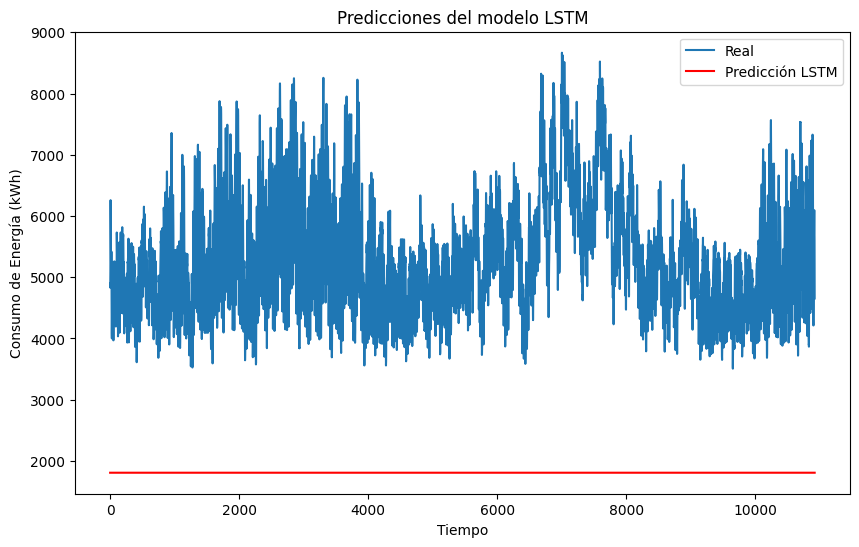

In [ ]:
# Define the LSTM model
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50))
    model.add(Dense(units=1))  # Output layer for a single prediction
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Assuming 'train' and 'test' DataFrames are already defined and preprocessed

# Prepare data for LSTM
def prepare_data(data, lookback):
  X, y = [], []
  for i in range(len(data) - lookback):
    X.append(data[i:(i + lookback)])
    y.append(data[i + lookback])
  return np.array(X), np.array(y)


lookback = 24  # Example: using the past 24 hours to predict the next hour
X_train, y_train = prepare_data(train['Energy'].values.reshape(-1, 1), lookback)
X_test, y_test = prepare_data(test['Energy'].values.reshape(-1, 1), lookback)

# Reshape input to be [samples, time steps, features] which is required for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Create and train the LSTM model
model_lstm = create_lstm_model((lookback, 1))
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32) # Adjust epochs and batch_size

# Make predictions
y_pred_lstm = model_lstm.predict(X_test)


# Evaluate the model (example with RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
print(f"RMSE del modelo LSTM: {rmse_lstm}")

# Visualize the predictions (adjust as needed)
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Real')
plt.plot(y_pred_lstm, label='Predicción LSTM', color='red')
plt.title('Predicciones del modelo LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de Energía (kWh)')
plt.legend()
plt.show()

<ipython-input-17-55128eb055bc>:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_row.append(data[i + j])
<ipython-input-17-55128eb055bc>:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  X_row.append(data[i + lookback + k -1 ])
<ipython-input-17-55128eb055bc>:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y.append(data[i + lookback + lag_steps -1])


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3561/3561 ━━━━━━━━━━━━━━━━━━━━ 121s 33ms/step - loss: 0.0059
Epoch 2/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 140s 33ms/step - loss: 2.0057e-04
Epoch 3/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 144s 33ms/step - loss: 1.6880e-04
Epoch 4/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 117s 33ms/step - loss: 1.3697e-04
Epoch 5/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 144s 33ms/step - loss: 1.2045e-04
Epoch 6/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 141s 33ms/step - loss: 1.2587e-04
Epoch 7/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 141s 33ms/step - loss: 1.1271e-04
Epoch 8/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 120s 34ms/step - loss: 9.9634e-05
Epoch 9/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 118s 33ms/step - loss: 9.8040e-05
Epoch 10/10
3561/3561 ━━━━━━━━━━━━━━━━━━━━ 129s 36ms/step - loss: 8.9140e-05
342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
RMSE del modelo LSTM: 76.53484778003572


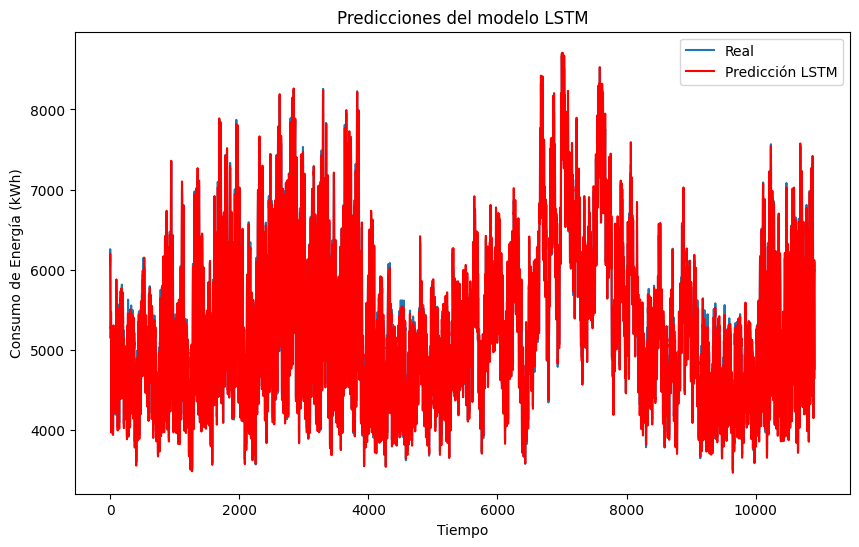

In [ ]:
#MISMO MODELO PERO ESTANDARIZAONDO LOS DATOS
# Scale data using MinMaxScaler
train_lstm = train.copy()
test_lstm = test.copy()

scaler = MinMaxScaler()
train_lstm['Energy_scaled'] = scaler.fit_transform(train_lstm['Energy'].values.reshape(-1, 1))
test_lstm['Energy_scaled'] = scaler.transform(test_lstm['Energy'].values.reshape(-1, 1))


# Prepare data for LSTM with lag features
def prepare_data_with_lags(data, lookback, lag_steps):
    X, y = [], []
    for i in range(len(data) - lookback - lag_steps + 1):
        X_row = []
        for j in range(lookback):
           X_row.append(data[i + j])
        for k in range(lag_steps):
            X_row.append(data[i + lookback + k -1 ])
        X.append(X_row)
        y.append(data[i + lookback + lag_steps -1])
    return np.array(X), np.array(y)


lookback = 24  # Example: using the past 24 hours
lag_steps = 7 # Example: using the next 7 hours

X_train, y_train = prepare_data_with_lags(train_lstm['Energy_scaled'], lookback, lag_steps)
X_test, y_test = prepare_data_with_lags(test_lstm['Energy_scaled'], lookback, lag_steps)


# Reshape input to be [samples, time steps, features] which is required for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model (Re-define the function here)
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=True, input_shape=input_shape))
    model.add(LSTM(units=50))
    model.add(Dense(units=1))  # Output layer for a single prediction
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Create and train the LSTM model
model_lstm = create_lstm_model((lookback + lag_steps -1, 1))
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32) # Adjust epochs and batch_size


# Make predictions
y_pred_lstm_scaled = model_lstm.predict(X_test)

# Inverse transform the predictions to the original scale
y_pred_lstm = scaler.inverse_transform(y_pred_lstm_scaled)
y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate the model (example with RMSE)
rmse_lstm = np.sqrt(mean_squared_error(y_test_original, y_pred_lstm))
print(f"RMSE del modelo LSTM: {rmse_lstm}")

# Visualize the predictions
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Real')
plt.plot(y_pred_lstm, label='Predicción LSTM', color='red')
plt.title('Predicciones del modelo LSTM')
plt.xlabel('Tiempo')
plt.ylabel('Consumo de Energía (kWh)')
plt.legend()
plt.show()

# Modelos Machine Learning

DEBUG:cmdstanpy:input tempfile: /tmp/tmp87c05_za/ekhiknqw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp87c05_za/cgzfcx1z.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=40635', 'data', 'file=/tmp/tmp87c05_za/ekhiknqw.json', 'init=/tmp/tmp87c05_za/cgzfcx1z.json', 'output', 'file=/tmp/tmp87c05_za/prophet_modelg3zd137m/prophet_model-20241218114836.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:48:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:48:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


Mean Squared Error (MSE): 695089.75
Mean Absolute Error (MAE): 667.05
Root Mean Squared Error (RMSE): 833.72


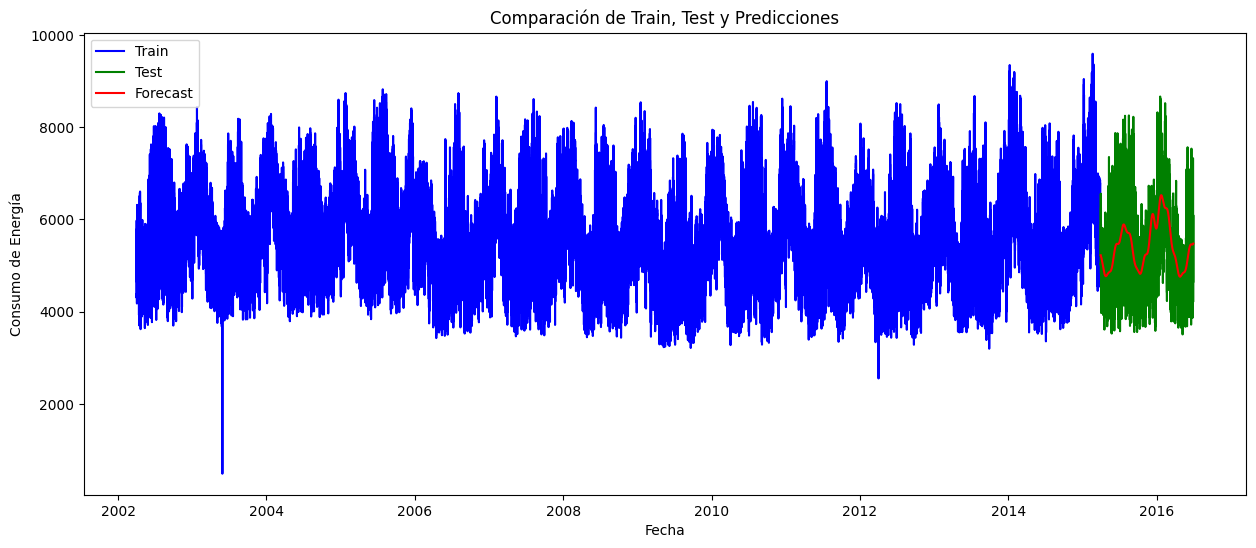

In [ ]:
# Preparar los datos
df = train.reset_index()[['Datetime', 'Energy']]
df.columns = ['ds', 'y']  # Prophet requiere que las columnas se llamen 'ds' (fecha) y 'y' (valor)

# Crear y configurar el modelo
model = Prophet(
    yearly_seasonality=True,  # Activa la estacionalidad predeterminada
    daily_seasonality=False,   # Desactiva la estacionalidad diaria
    weekly_seasonality=False,   # Desactiva la estacionalidad semanal
    changepoint_prior_scale=0.0001,
    seasonality_mode='multiplicative'
)

# Ajustar el modelo
model.fit(df)

df_test = test.reset_index()[['Datetime', 'Energy']]
df_test.columns = ['ds', 'y']  # Prophet requiere que las columnas se llamen 'ds' (fecha) y 'y' (valor)

future = model.make_future_dataframe(periods=len(df_test), freq='h')  # 'H' para datos horarios
forecast = model.predict(future)

# Extraer solo las predicciones para el conjunto de prueba
forecast_test = forecast[forecast['ds'].isin(df_test['ds'])]

# Calcular métricas de error
mse = mean_squared_error(df_test['y'], forecast_test['yhat'])
mae = mean_absolute_error(df_test['y'], forecast_test['yhat'])
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Comparar visualmente train, test y las predicciones
plt.figure(figsize=(15, 6))

# Visualizar datos de entrenamiento
plt.plot(df['ds'], df['y'], label='Train', color='blue')

# Visualizar datos reales de prueba
plt.plot(df_test['ds'], df_test['y'], label='Test', color='green')

# Visualizar predicciones del modelo
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Forecast', color='red')

plt.xlabel('Fecha')
plt.ylabel('Consumo de Energía')
plt.title('Comparación de Train, Test y Predicciones')
plt.legend()
plt.show()

# Modelos clásicos

No se ha implementado Sarima por falta de recursos computacionales.

In [ ]:
'''# Crear el modelo ETS
model_ets = ExponentialSmoothing(train['Energy'], trend='add', seasonal='add', seasonal_periods=8760) # Ajusta los parámetros según tus necesidades

# Ajustar el modelo
model_fit_ets = model_ets.fit()

# Realizar predicciones
predictions_ets = model_fit_ets.predict(start=len(train), end=len(train) + len(test) - 1)

# Evaluar el modelo (ejemplo con RMSE)
rmse_ets = np.sqrt(mean_squared_error(test['Energy'], predictions_ets))
print(f"RMSE del modelo ETS: {rmse_ets}")

# Visualizar las predicciones
plt.figure(figsize=(10, 6))
plt.plot(test['Energy'], label='Real')
plt.plot(predictions_ets, label='Predicción ETS', color='green')
plt.title('Predicciones del modelo ETS')
plt.xlabel('Fecha')
plt.ylabel('Consumo de Energía (kWh)')
plt.legend()
plt.show()'''

'# Crear el modelo ETS\nmodel_ets = ExponentialSmoothing(train[\'Energy\'], trend=\'add\', seasonal=\'add\', seasonal_periods=8760) # Ajusta los parámetros según tus necesidades\n\n# Ajustar el modelo\nmodel_fit_ets = model_ets.fit()\n\n# Realizar predicciones\npredictions_ets = model_fit_ets.predict(start=len(train), end=len(train) + len(test) - 1)\n\n# Evaluar el modelo (ejemplo con RMSE)\nrmse_ets = np.sqrt(mean_squared_error(test[\'Energy\'], predictions_ets))\nprint(f"RMSE del modelo ETS: {rmse_ets}")\n\n# Visualizar las predicciones\nplt.figure(figsize=(10, 6))\nplt.plot(test[\'Energy\'], label=\'Real\')\nplt.plot(predictions_ets, label=\'Predicción ETS\', color=\'green\')\nplt.title(\'Predicciones del modelo ETS\')\nplt.xlabel(\'Fecha\')\nplt.ylabel(\'Consumo de Energía (kWh)\')\nplt.legend()\nplt.show()'

In [ ]:
'''# Crear el modelo SARIMA
# (P, D, Q, S) son los parámetros estacionales
model = SARIMAX(train['Energy'],
                order=(1, 1, 0),                # ARIMA no estacional: p=1, d=1, q=0
                seasonal_order=(1, 1, 1, 8760), # Estacionalidad anual (8760 horas en un año)
                enforce_stationarity=False,
                enforce_invertibility=False)

# Ajustar el modelo
model_fit = model.fit(disp=False)

# Ver los resultados del ajuste
print(model_fit.summary())'''

"# Crear el modelo SARIMA\n# (P, D, Q, S) son los parámetros estacionales\nmodel = SARIMAX(train['Energy'],\n                order=(1, 1, 0),                # ARIMA no estacional: p=1, d=1, q=0\n                seasonal_order=(1, 1, 1, 8760), # Estacionalidad anual (8760 horas en un año)\n                enforce_stationarity=False,\n                enforce_invertibility=False)\n\n# Ajustar el modelo\nmodel_fit = model.fit(disp=False)\n\n# Ver los resultados del ajuste\nprint(model_fit.summary())"

## Modelos Boost

MAE: 48.78722194203159
RMSE: 64.43689230815141


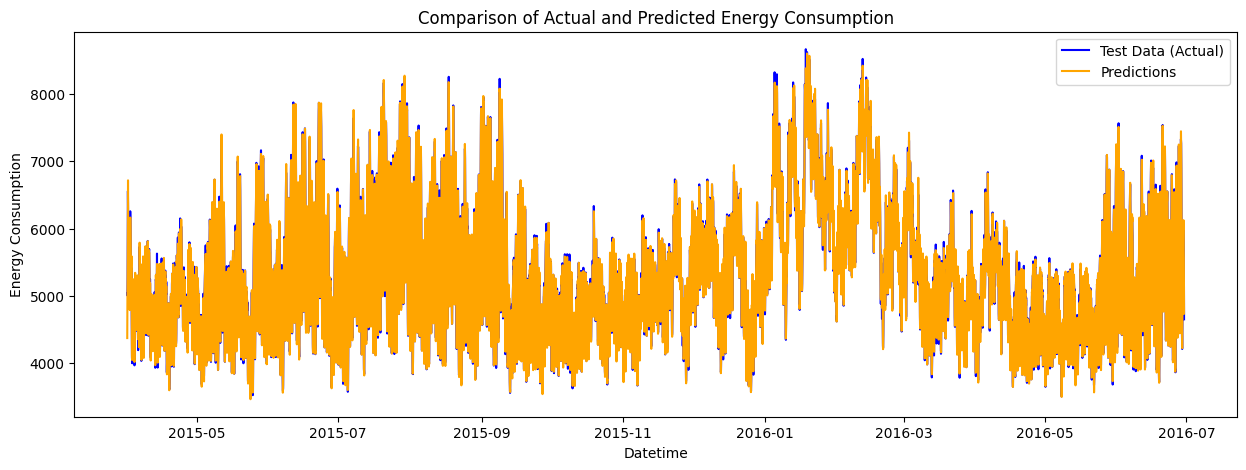

In [ ]:
#MODELO XGBOOST PARA PRUEBA
from xgboost import XGBRegressor
# Crear funciones para características (lag y rolling)
def create_features(df, lags, rolling_windows):
    df_copy = df.copy()
    new_features = {}

    # Crear características de lag
    for lag in range(1, lags + 1):
        new_features[f'lag_{lag}'] = df_copy['Energy'].shift(lag)

    # Crear características de rolling (promedios)
    for window in rolling_windows:
        new_features[f'rolling_mean_{window}'] = df_copy['Energy'].rolling(window=window).mean()

    # Características temporales horarias (convertir a Series)
    new_features['dayofweek'] = pd.Series(df_copy.index.dayofweek, index=df_copy.index)
    new_features['month'] = pd.Series(df_copy.index.month, index=df_copy.index)
    new_features['hour'] = pd.Series(df_copy.index.hour, index=df_copy.index)
    new_features['dayofyear'] = pd.Series(df_copy.index.dayofyear, index=df_copy.index)

    # Concatenar todas las nuevas características
    new_features_df = pd.concat(new_features, axis=1)

    # Rellenar NaN de las nuevas columnas
    new_features_df = new_features_df.ffill()

    # Combinar las nuevas características con el DataFrame original
    df_copy = pd.concat([df_copy, new_features_df], axis=1)

    return df_copy

# Crear características de entrenamiento
lags = 168  # Usar la última semana como input
rolling_windows = [168, 672]  # Ventanas de 1 semana y 1 mes
train_features = create_features(train, lags, rolling_windows)
test_features = create_features(test, lags, rolling_windows)

# Separar en características (X) y variable objetivo (y)
X_train = train_features.drop(columns=['Energy'])
y_train = train_features['Energy']
X_test = test_features.drop(columns=['Energy'])
y_test = test_features['Energy']

# Crear el modelo XGBoost
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=11,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones
y_pred = model.predict(X_test)

# Evaluación del modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")

# Visualización de los resultados
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label='Test Data (Actual)', color='blue')
plt.plot(y_test.index, y_pred, label='Predictions', color='orange')
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption')
plt.title('Comparison of Actual and Predicted Energy Consumption')
plt.legend()
plt.show()


<ipython-input-22-18346a2142ea>:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy[col] = df_copy[col].fillna(method='ffill')  # Rellenar con el último valor conocido
<ipython-input-22-18346a2142ea>:23: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy[col] = df_copy[col].fillna(method='ffill')  # Rellenar con el último valor conocido


0:	learn: 885.7937688	total: 303ms	remaining: 9m 4s
200:	learn: 66.5737061	total: 56.7s	remaining: 7m 31s
400:	learn: 56.6987711	total: 1m 50s	remaining: 6m 25s
600:	learn: 51.4320463	total: 2m 47s	remaining: 5m 33s
800:	learn: 47.6371938	total: 3m 43s	remaining: 4m 38s
1000:	learn: 44.7121604	total: 4m 37s	remaining: 3m 41s
1200:	learn: 42.2560877	total: 5m 34s	remaining: 2m 46s
1400:	learn: 40.0704166	total: 6m 31s	remaining: 1m 51s
1600:	learn: 38.1085592	total: 7m 25s	remaining: 55.3s
1799:	learn: 36.3820711	total: 8m 21s	remaining: 0us
MAE: 44.148790976001884
RMSE: 58.00714368863894


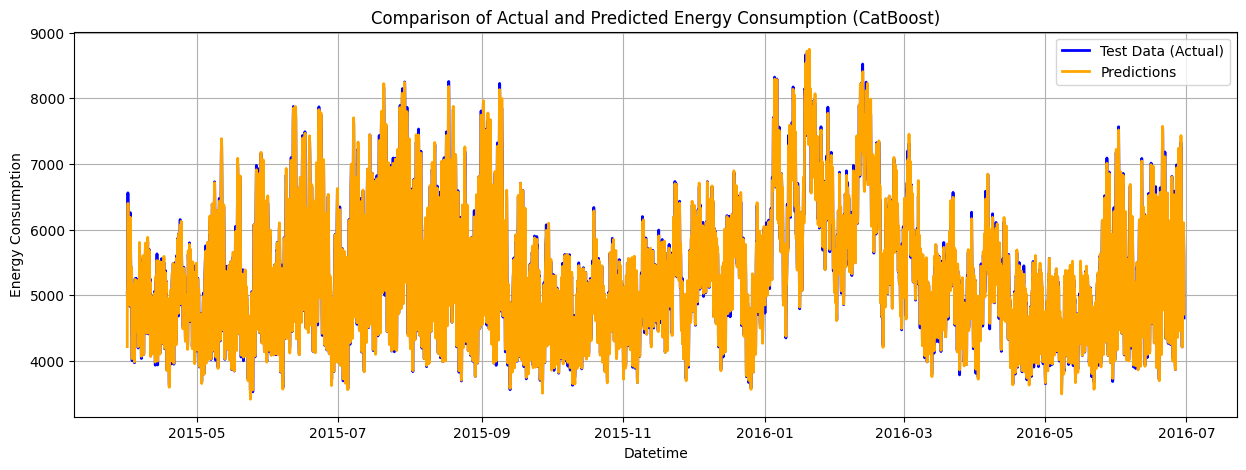

In [ ]:
#MODELO CATBOOST PARA PRUEBA
def create_features(df, lags, rolling_windows):
    df_copy = df.copy()

    # Crear características de lag
    for lag in range(1, lags + 1):
        df_copy[f'lag_{lag}'] = df_copy['Energy'].shift(lag)

    # Crear características de rolling (promedios)
    for window in rolling_windows:
        df_copy[f'rolling_mean_{window}'] = df_copy['Energy'].rolling(window=window).mean()

    # Características temporales horarias
    df_copy['dayofweek'] = df_copy.index.dayofweek
    df_copy['month'] = df_copy.index.month
    df_copy['hour'] = df_copy.index.hour
    df_copy['dayofyear'] = df_copy.index.dayofyear

    # Aquí manejamos los NaN que provienen de los lags y ventanas rodantes para las fechas de predicción
    # Una opción es llenar hacia adelante o usar otra estrategia de imputación para las características
    for col in df_copy.columns:
        if col != 'Energy':
            df_copy[col] = df_copy[col].fillna(method='ffill')  # Rellenar con el último valor conocido

    # Elimina filas donde 'Energy' es NaN solo si estás trabajando con datos de entrenamiento
    # Para predicción, queremos mantener todas las filas, incluso si 'Energy' está vacío
    return df_copy

# Crear características de entrenamiento
lags = 48  # Usar las últimas 48 horas como input
rolling_windows = [48, 336]  # Ventanas de 2 dias y 2 semanas
train_features = create_features(train, lags, rolling_windows)
test_features = create_features(test, lags, rolling_windows)

# Separar en características (X) y variable objetivo (y)
X_train = train_features.drop(columns=['Energy'])
y_train = train_features['Energy']
X_test = test_features.drop(columns=['Energy'])
y_test = test_features['Energy']

# Crear el modelo CatBoost
model = CatBoostRegressor(
    iterations=1800,             # Número de iteraciones
    learning_rate=0.1,          # Tasa de aprendizaje
    depth=10,                     # Profundidad del árbol
    loss_function='RMSE',        # Función de pérdida
    verbose=200                  # Mostrar progreso cada 200 iteraciones
)

# Entrenar el modelo
model.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

# Visualizar los resultados
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label='Test Data (Actual)', color='blue', linewidth=2)
plt.plot(y_test.index, y_pred, label='Predictions', color='orange', linewidth=2)
plt.xlabel('Datetime')
plt.ylabel('Energy Consumption')
plt.title('Comparison of Actual and Predicted Energy Consumption (CatBoost)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#MODELO XGBOOST PARA PREDICCION
# Generar el rango de fechas para las predicciones
prediction_datesxg = pd.date_range(start='2016-07-01 00:00:00', end='2018-12-31 23:00:00', freq='h')

# Crear un DataFrame con estas fechas y una columna 'Energy' con valores NaN o cualquier valor dummy
predict_dataxg = pd.DataFrame(index=prediction_datesxg, columns=['Energy'])
predict_dataxg['Energy'] = np.nan  # O cualquier valor dummy

# Combinar datos históricos con las fechas de predicción para crear características
combined_dataxg = pd.concat([energy, predict_dataxg], axis=0)

def create_features(df, lags, rolling_windows):
    df_copy = df.copy()
    new_features = {}

    # Crear características de lag
    for lag in range(1, lags + 1):
        new_features[f'lag_{lag}'] = df_copy['Energy'].shift(lag)

    # Crear características de rolling (promedios)
    for window in rolling_windows:
        new_features[f'rolling_mean_{window}'] = df_copy['Energy'].rolling(window=window).mean()

    # Características temporales horarias (convertir a Series)
    new_features['dayofweek'] = pd.Series(df_copy.index.dayofweek, index=df_copy.index)
    new_features['month'] = pd.Series(df_copy.index.month, index=df_copy.index)
    new_features['hour'] = pd.Series(df_copy.index.hour, index=df_copy.index)
    new_features['dayofyear'] = pd.Series(df_copy.index.dayofyear, index=df_copy.index)

    # Concatenar todas las nuevas características
    new_features_df = pd.concat(new_features, axis=1)

    # Rellenar NaN de las nuevas columnas
    new_features_df = new_features_df.ffill()

    # Combinar las nuevas características con el DataFrame original
    df_copy = pd.concat([df_copy, new_features_df], axis=1)

    return df_copy

# Configuración de características
lags = 168  # Usar la última semana como input
rolling_windows = [168, 672]  # Ventanas de 1 semana y 1 mes
combined_featuresxg = create_features(combined_dataxg, lags, rolling_windows)

# Dividir datos en entrenamiento y predicción
train_dataxg = combined_featuresxg.loc[combined_featuresxg.index <= '2016-06-30 00:00:00']
predict_dataxg = combined_featuresxg.loc[combined_featuresxg.index >= '2016-07-30 00:00:00']

X_trainxg = train_dataxg.drop('Energy', axis=1)
y_trainxg = train_dataxg['Energy']
X_predictxg = predict_dataxg.drop('Energy', axis=1)  # Aquí está bien, X_predict ahora es un DataFrame con las características

# Crear el modelo XGBoost
modelxg = XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

modelxg.fit(X_trainxg, y_trainxg)

predictionsxg = modelxg.predict(X_predictxg)

# Crear un DataFrame con las predicciones
predictions_dfxg = pd.DataFrame({
    'Datetime': X_predictxg.index,
    'Predicted_Energy': predictionsxg
})

# Guardar o mostrar las predicciones
predictions_dfxg.to_csv('predictions_2016_2018xg.csv', index=False)
print(predictions_dfxg.tail(50))

                 Datetime  Predicted_Energy
21190 2018-12-29 22:00:00       4710.964844
21191 2018-12-29 23:00:00       4657.879883
21192 2018-12-30 00:00:00       4544.766602
21193 2018-12-30 01:00:00       4544.766602
21194 2018-12-30 02:00:00       4596.821777
21195 2018-12-30 03:00:00       4637.136230
21196 2018-12-30 04:00:00       4640.791016
21197 2018-12-30 05:00:00       4722.926758
21198 2018-12-30 06:00:00       4782.412109
21199 2018-12-30 07:00:00       4784.223633
21200 2018-12-30 08:00:00       4766.128906
21201 2018-12-30 09:00:00       4767.102539
21202 2018-12-30 10:00:00       4767.102539
21203 2018-12-30 11:00:00       4736.357910
21204 2018-12-30 12:00:00       4713.657227
21205 2018-12-30 13:00:00       4713.657227
21206 2018-12-30 14:00:00       4713.657227
21207 2018-12-30 15:00:00       4713.657227
21208 2018-12-30 16:00:00       4713.657227
21209 2018-12-30 17:00:00       4715.721191
21210 2018-12-30 18:00:00       4722.166504
21211 2018-12-30 19:00:00       

In [ ]:
#MODELO CATBOOST PARA PREDICCION
# Generar el rango de fechas para las predicciones
prediction_dates = pd.date_range(start='2016-07-01 00:00:00', end='2018-12-31 23:00:00', freq='h')

# Crear un DataFrame con estas fechas y una columna 'Energy' con valores NaN o cualquier valor dummy
predict_data = pd.DataFrame(index=prediction_dates, columns=['Energy'])
predict_data['Energy'] = np.nan  # O cualquier valor dummy

# Combinar datos históricos con las fechas de predicción para crear características
combined_data = pd.concat([energy, predict_data], axis=0)

def create_features(df, lags, rolling_windows):
    df_copy = df.copy()

    # Crear características de lag
    for lag in range(1, lags + 1):
        df_copy[f'lag_{lag}'] = df_copy['Energy'].shift(lag)

    # Crear características de rolling (promedios)
    for window in rolling_windows:
        df_copy[f'rolling_mean_{window}'] = df_copy['Energy'].rolling(window=window).mean()

    # Características temporales horarias
    df_copy['dayofweek'] = df_copy.index.dayofweek
    df_copy['month'] = df_copy.index.month
    df_copy['hour'] = df_copy.index.hour
    df_copy['dayofyear'] = df_copy.index.dayofyear

    # Aquí manejamos los NaN que provienen de los lags y ventanas rodantes para las fechas de predicción
    # Una opción es llenar hacia adelante o usar otra estrategia de imputación para las características
    for col in df_copy.columns:
        if col != 'Energy':
            df_copy[col] = df_copy[col].fillna(method='ffill')  # Rellenar con el último valor conocido

    # Elimina filas donde 'Energy' es NaN solo si estás trabajando con datos de entrenamiento
    # Para predicción, queremos mantener todas las filas, incluso si 'Energy' está vacío
    return df_copy

# Configuración
lags = 48  # Usar las últimas 48 horas como input
rolling_windows = [48, 336]  # Ventanas de 2 dias y 2 semanas

# Configuración de características

combined_features = create_features(combined_data, lags, rolling_windows)

# Dividir datos en entrenamiento y predicción
train_data = combined_features.loc[combined_features.index <= '2016-06-30 00:00:00']
predict_data = combined_features.loc[combined_features.index >= '2016-07-30 00:00:00']

X_train = train_data.drop('Energy', axis=1)
y_train = train_data['Energy']
X_predict = predict_data.drop('Energy', axis=1)  # Aquí está bien, X_predict ahora es un DataFrame con las características

# Crear el modelo CatBoost
model = CatBoostRegressor(
    iterations=2000,             # Número de iteraciones
    learning_rate=0.1,          # Tasa de aprendizaje
    depth=8,                     # Profundidad del árbol
    loss_function='RMSE',        # Función de pérdida
    verbose=200                  # Mostrar progreso cada 200 iteraciones
)
model.fit(X_train, y_train)

predictions = model.predict(X_predict)

# Crear un DataFrame con las predicciones
predictions_df = pd.DataFrame({
    'Datetime': X_predict.index,
    'Predicted_Energy': predictions
})

# Guardar o mostrar las predicciones
predictions_df.to_csv('predictions_2016_2018cat.csv', index=False)
print(predictions_df.tail(50))

<ipython-input-24-aa41f9e80bf8>:33: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_copy[col] = df_copy[col].fillna(method='ffill')  # Rellenar con el último valor conocido


0:	learn: 887.7117606	total: 105ms	remaining: 3m 30s
200:	learn: 71.5242458	total: 18.4s	remaining: 2m 44s
400:	learn: 62.1708833	total: 37.2s	remaining: 2m 28s
600:	learn: 57.4843031	total: 57.6s	remaining: 2m 14s
800:	learn: 54.3586801	total: 1m 16s	remaining: 1m 53s
1000:	learn: 52.0282689	total: 1m 34s	remaining: 1m 34s
1200:	learn: 50.0847561	total: 1m 53s	remaining: 1m 15s
1400:	learn: 48.4352007	total: 2m 14s	remaining: 57.4s
1600:	learn: 46.9755274	total: 2m 32s	remaining: 38s
1800:	learn: 45.6471323	total: 2m 51s	remaining: 18.9s
1999:	learn: 44.4517249	total: 3m 10s	remaining: 0us
                 Datetime  Predicted_Energy
21190 2018-12-29 22:00:00       4617.814083
21191 2018-12-29 23:00:00       4546.852026
21192 2018-12-30 00:00:00       4459.577670
21193 2018-12-30 01:00:00       4473.228858
21194 2018-12-30 02:00:00       4567.125667
21195 2018-12-30 03:00:00       4600.090294
21196 2018-12-30 04:00:00       4621.996875
21197 2018-12-30 05:00:00       4630.102310
21198 